# 01｜图片数据与四维 Tensor

本页不训练模型。我们把一张手写数字同时看成图片、像素矩阵和 PyTorch Tensor。

In [1]:
%matplotlib inline
from pathlib import Path
import sys

LAB_DIR = Path.cwd()
if not (LAB_DIR / "cnn_lab").is_dir():
    LAB_DIR = (LAB_DIR / "02_cnn_lab").resolve()
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))

from cnn_lab import load_digits_data, show_data

## 1｜从一张图片到一个 Batch

监督学习数据集仍写成：

$$
\mathcal{D}=\{(\mathbf{X}_i,y_i)\}_{i=1}^{N}
$$

图像样本是带通道的矩阵：

$$
\mathbf{X}_i\in[0,1]^{C\times H\times W},
\qquad y_i\in\{0,1,\ldots,9\}
$$

把 $B$ 张图片组成一个 Batch：

$$
\mathbf{X}_{\mathrm{batch}}\in\mathbb{R}^{B\times C\times H\times W}
$$

当前灰度数字为 $C=1,H=W=8$；以后换成 28×28 时，主要变化是 $H=W=28$。

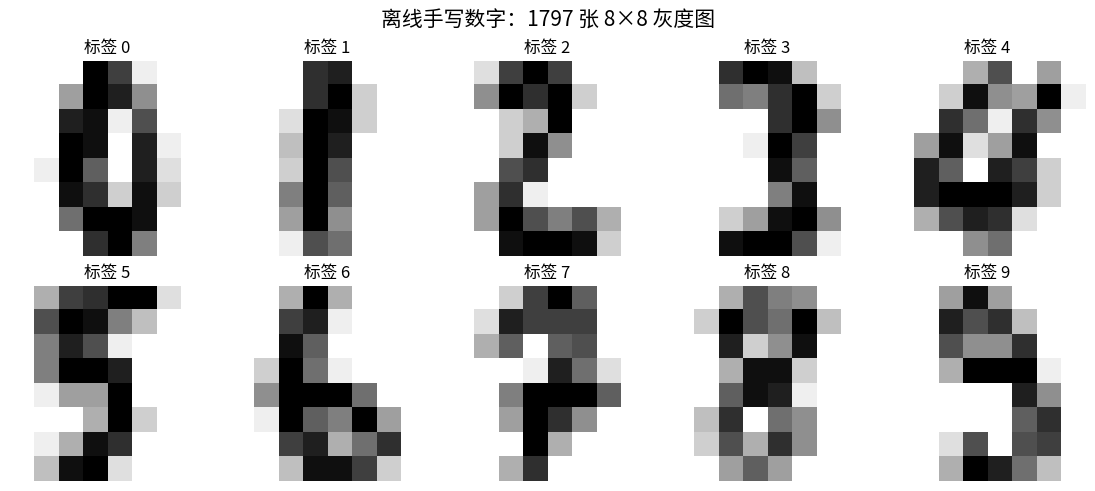

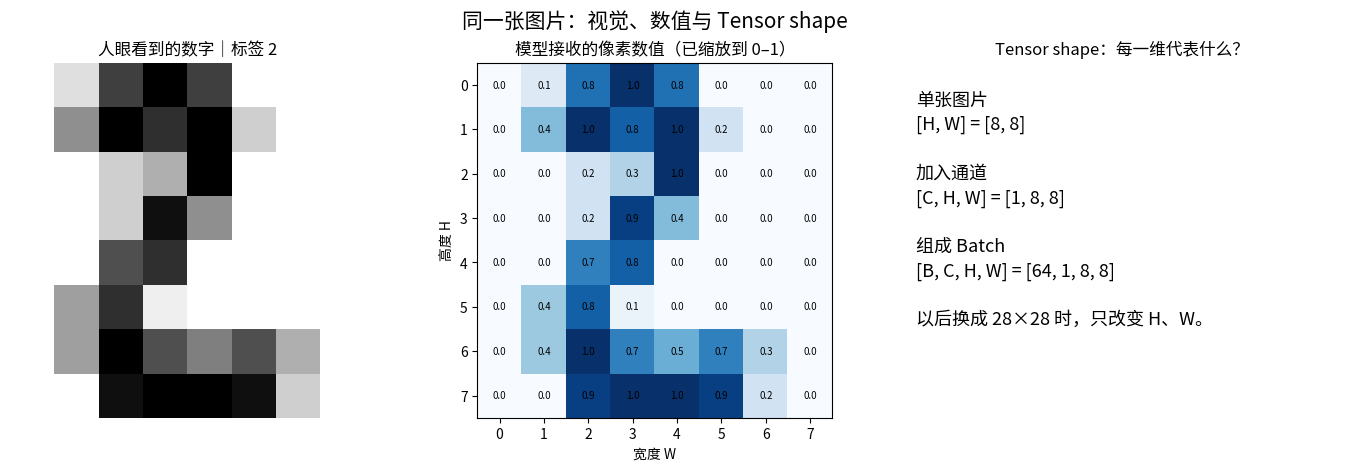

In [2]:
data = load_digits_data(seed=42)
gallery_figure, pixel_figure = show_data(data)

## 2｜直接检查 Tensor shape

按顺序读维度：Batch、Channel、Height、Width。灰度图只有 1 个通道，不代表它没有通道维。

In [3]:
print("训练图片：", tuple(data.x_train.shape), "= [N, C, H, W]")
print("训练标签：", tuple(data.y_train.shape), "= [N]")
print("单张图片：", tuple(data.x_train[0].shape), "= [C, H, W]")
print("像素范围：", float(data.x_train.min()), "到", float(data.x_train.max()))
print("类别名称：", data.class_names)

训练图片： (1347, 1, 8, 8) = [N, C, H, W]
训练标签： (1347,) = [N]
单张图片： (1, 8, 8) = [C, H, W]
像素范围： 0.0 到 1.0
类别名称： ('0', '1', '2', '3', '4', '5', '6', '7', '8', '9')


**概念检查：**如果 Batch size 为 64，输入改成 28×28 灰度图，shape 是什么？

<details><summary>参考答案</summary>
`[64, 1, 28, 28]`。64 是一次输入的图片数，1 是灰度通道，最后两维是高度和宽度。
</details>

不要把图片一开始就压平成 `[B, 784]`；CNN 正是利用最后两维保存的空间邻接关系。

## 完成本页后：释放资源并结束内核

运行下面的最后一个单元格。它会依次清空变量、关闭图片、释放未使用的 CUDA 缓存，并向 Jupyter 内核发送正常关机请求。

运行后，VS Code 可能显示“内核已停止”“请选择内核”或暂时断开连接，这是正常现象，表示当前 Notebook 的 Python 进程已经结束。再次实验时，重新选择 Python 内核即可。

In [4]:
%reset -f
import gc
import matplotlib.pyplot as plt
import torch
from IPython import get_ipython

plt.close("all")
gc.collect()

# 先释放当前进程中未使用的 CUDA 缓存。
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("清理完成，正在结束当前 Notebook 的 Python 内核……")

# 正常关闭当前 Jupyter 内核；再次运行时需要重新选择内核。
get_ipython().kernel.do_shutdown(restart=False)


清理完成，正在结束当前 Notebook 的 Python 内核……


{'status': 'ok', 'restart': False}